## Libraries Loaded
Import required libraries for data analysis, preprocessing, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os

from imblearn.over_sampling import SMOTE

print("Libraries installed successfully!")

Libraries installed successfully!


In [2]:
# ── Global Plot Style
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.35,
    'grid.linestyle'  : '--',
})
sns.set_style("darkgrid")

# Consistent colour palette used throughout
C = {
    'green'  : '#27ae60',
    'red'    : '#e74c3c',
    'blue'   : '#2980b9',
    'orange' : '#e67e22',
    'purple' : '#8e44ad',
    'teal'   : '#16a085',
    'gray'   : '#7f8c8d',
}
MODEL_COLORS = [C['red'], C['blue'], C['green'], C['orange']]

## scripts/load_dataset.py
Load the PaySim dataset containing synthetic financial transaction records used for fraud detection analysis.

In [3]:
def load_dataset(path):
    """
    Load dataset from CSV file with optimized data types to reduce memory usage
    """

    # Define optimized dtypes to reduce memory footprint
    dtype_dict = {
        'step': 'int32',
        'type': 'category',
        'amount': 'float32',
        'nameOrig': 'category',
        'oldbalanceOrg': 'float32',
        'newbalanceOrig': 'float32',
        'nameDest': 'category',
        'oldbalanceDest': 'float32',
        'newbalanceDest': 'float32',
        'isFraud': 'int8',
        'isFlaggedFraud': 'int8',
    }    
    df = pd.read_csv(path, dtype=dtype_dict)

    print("Dataset Loaded Successfully")
    print("Shape:", df.shape)
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return df

# Load dataset using the function
dataset_path = r"E:\Documents\Artifical Intelligence\AI Project\AI_Project_Dilverable 1\Dataset\PaySim - Synthetic Financial Dataset for Fraud Detection.csv"
df = load_dataset(dataset_path)

Dataset Loaded Successfully
Shape: (6362620, 11)
Memory Usage: 920.71 MB


## scripts/basic_inspection.py
Perform initial dataset inspection including shape, column names, data types, and statistical summary to understand the dataset structure.

In [4]:
def dataset_shape(df):
    """
    Display number of rows and columns
    """
    print("Dataset Shape:", df.shape)

In [5]:
dataset_shape(df)

Dataset Shape: (6362620, 11)


In [6]:
def dataset_columns(df):
    """
    Display column names
    """
    print("Columns:")
    print(df.columns)

In [7]:
dataset_columns(df)

Columns:
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [8]:
def dataset_datatypes(df):
    """
    Display datatypes of each column
    """
    print("Data Types:")
    print(df.dtypes)

In [9]:
dataset_datatypes(df)

Data Types:
step                 int32
type              category
amount             float32
nameOrig          category
oldbalanceOrg      float32
newbalanceOrig     float32
nameDest          category
oldbalanceDest     float32
newbalanceDest     float32
isFraud               int8
isFlaggedFraud        int8
dtype: object


In [10]:
def dataset_info(df):
    """
    Display overall info of the entire dataset
    """
    print("Dataset Info:", df.info())

In [11]:
dataset_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        category
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        category
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(3), float32(5), int32(1), int8(2)
memory usage: 475.1 MB
Dataset Info: None


In [12]:
def dataset_description(df):
    """
    Statistical summary of dataset
    """
    print("Dataset Statistical Summary:")
    print(df.describe())

In [13]:
dataset_description(df)

Dataset Statistical Summary:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338834e+05    8.551137e+05   
std    1.423320e+02  5.991358e+05   2.831753e+06    2.862818e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06  
mean     1.100702e+06    1.224997e+06  1.290820e-03    2.514687e-06  
std      3.369338e+06    3.629806e+06  3.590480e-02    1.585775e-03  
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00  
25%     

In [14]:
def missing_values(df):
    """
    Check missing values in dataset
    """
    print("Missing Values:")
    print(df.isnull().sum())

In [15]:
missing_values(df)

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [16]:
def dataset_fraud(df):
    """
    Display fraud distribution
    """
    print(df['isFraud'].value_counts(normalize=True))

In [17]:
dataset_fraud(df)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [18]:
def dataset_head(df):
    """
    Display first rows
    """
    print("First 5 Rows:")
    print(df.head())

In [19]:
dataset_head(df)

First 5 Rows:
   step      type        amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.639648  C1231006815       170136.0   160296.359375   
1     1   PAYMENT   1864.280029  C1666544295        21249.0    19384.720703   
2     1  TRANSFER    181.000000  C1305486145          181.0        0.000000   
3     1  CASH_OUT    181.000000   C840083671          181.0        0.000000   
4     1   PAYMENT  11668.139648  C2048537720        41554.0    29885.859375   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


## scripts/data_cleaning.py
Check for missing values to ensure data quality before performing preprocessing and analysis.

In [20]:
def remove_duplicates(df):
    """
    Remove duplicate rows
    """

    before = df.shape[0]

    df = df.drop_duplicates()

    after = df.shape[0]

    print("Duplicates removed:", before - after)

    return df

In [21]:
def drop_null(df):
    """
    Remove duplicate rows
    """

    before = df.shape[0]

    df = df.dropna()

    after = df.shape[0]

    print("Drop missing or null values:", before - after)

    return df

## scripts/feature_engineering.py
Convert categorical variables into numerical form by using LabelEnoder so they can be used by machine learning models.

In [22]:
def feature_engineering(df):
    df = df.copy()

    df['balanceDiff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
    df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

    print("Feature Engineering is Done!")
    return df

In [23]:
def encode_features(df):
    """
    Convert categorical type columns into numeric values/ Do one-hot encoding

    """

    df = pd.get_dummies(df, columns=['type'], drop_first=True)
    print("Feature encoding done.")
    return df

## scripts/preprocessing_pipeline.py

Feature scaling was applied to numerical variables using StandardScaler to normalize the distribution of transaction-related variables. This step ensures that features with larger ranges do not dominate the learning process of machine learning models.


In [24]:
def preprocess_data(df):

    df = remove_duplicates(df)
    df = drop_null(df)
    df = feature_engineering(df)
    df = encode_features(df)

    return df

In [25]:
# Return the processed DataFrame
#return df
print("PREPROCESSING STARTED")
# Use existing preprocess_data function
df = preprocess_data(df)

print("\nPREPROCESING COMPLETED!")
print(f"Processed shape: {df.shape}")

df.head()

PREPROCESSING STARTED
Duplicates removed: 0
Drop missing or null values: 0
Feature Engineering is Done!
Feature encoding done.

PREPROCESING COMPLETED!
Processed shape: (6362620, 16)


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,amount_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,9839.640625,0.057834,False,False,True,False
1,1,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,1864.279297,0.087731,False,False,True,False
2,1,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,181.000000,0.994505,False,False,False,True
3,1,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,181.000000,0.994505,True,False,False,False
4,1,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,11668.140625,0.280788,False,False,True,False


In [26]:
# Fraud vs Non-Fraud distribution
# Fraud detection datasets are typically highly imbalanced,
# meaning fraudulent transactions represent a very small
# percentage of the total transactions.

fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)

fraud_percentage = df["isFraud"].value_counts(normalize=True) * 100

print("\nFraud Percentage:")
print(fraud_percentage)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


## scripts/train_test_split.py

In [27]:
# Step 4: Split
# Ensure df is the preprocessed DataFrame before this step.
# Also drop 'nameOrig' and 'nameDest' as they are object types and not used in simulation.
X = df.drop(['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
y = df['isFraud']

In [28]:
# Save feature names for later (visualizations, error analysis)
FEATURE_NAMES = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [29]:
print("Train size :", X_train.shape)
print("Test  size :", X_test.shape)
print("Train fraud ratio:", round(y_train.mean(), 4))
print("Test  fraud ratio:", round(y_test.mean(), 4))

Train size : (5090096, 12)
Test  size : (1272524, 12)
Train fraud ratio: 0.0013
Test  fraud ratio: 0.0013


## scripts/fraud_simulation_engine.py

In [30]:
def fraud_simulation_engine(X_train, y_train):
    """
    Inject synthetic fraud based on realistic patterns.
    Takes 5% of normal transactions and perturbs their financial features
    to resemble fraudulent behaviour (large amounts, drained balances).
    Optimized to minimize memory allocation.
    """

    df_temp = X_train.copy()
    df_temp['isFraud'] = y_train.values

    normal_tx = df_temp[df_temp['isFraud'] == 0]

    # Sample without extra copy
    synthetic = normal_tx.sample(frac=0.05, random_state=42)

    # Fraud patterns - modify in place
    synthetic['amount'] *= np.random.uniform(2, 5, size=len(synthetic))
    synthetic['balanceDiff'] *= np.random.uniform(0.1, 0.5, size=len(synthetic))
    synthetic['amount_ratio'] *= np.random.uniform(2, 6, size=len(synthetic))

    synthetic['isFraud'] = 1

    df_aug = pd.concat([df_temp, synthetic], ignore_index = True)

    X_aug = df_aug.drop('isFraud', axis=1)
    y_aug = df_aug['isFraud']

    print("Fraud Simulation Completed")
    print("Augmented fraud ratio:", round(y_aug.mean(), 4))

    return X_aug, y_aug

In [31]:
# Step 6: Fraud Simulation
X_train_aug, y_train_aug = fraud_simulation_engine(X_train, y_train)

Fraud Simulation Completed
Augmented fraud ratio: 0.0488


In [32]:
print("Final Train Fraud Ratio:", y_train_aug.mean())

Final Train Fraud Ratio: 0.04878980710562636


In [33]:
df_aug = pd.concat([X_train_aug, y_train_aug], axis=1)
df_aug.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiff,amount_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
0,15,9914.740234,44248.0,3.433326e+04,0.000000e+00,0.000000e+00,9914.738281,0.224067,False,False,True,False,0
1,20,6854.529785,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,6854.529785,False,False,True,False,0
2,231,361211.812500,0.0,0.000000e+00,4.897452e+05,8.509569e+05,0.000000,361211.812500,True,False,False,False,0
3,236,7083.509766,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,7083.509766,False,False,True,False,0
4,143,218019.515625,13045686.0,1.326370e+07,2.438124e+06,2.220104e+06,-218019.000000,0.016712,False,False,False,False,0


In [34]:
# Fraud vs Non-Fraud distribution
# Fraud detection datasets are typically highly imbalanced,
# meaning fraudulent transactions represent a very small
# percentage of the total transactions.

fraud_counts = df_aug["isFraud"].value_counts()

print(fraud_counts)

fraud_percentage = df_aug["isFraud"].value_counts(normalize=True) * 100

print("\nFraud Percentage:")
print(fraud_percentage)

isFraud
0    5083526
1     260746
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    95.121019
1     4.878981
Name: proportion, dtype: float64


## scripts/smote.py

In [35]:
def apply_smote(X_train, y_train, sampling_ratio=0.1):
    """
    Apply SMOTE to balance dataset.
    sampling_ratio=0.1 means the minority class will reach
    10% of the size of the majority class (reduced to prevent excessive synthetic data).
    """

    # BUG FIX #2: Reduced sampling_ratio from 0.5 to 0.1 to prevent 40-60% training set bloat
    smote = SMOTE(sampling_strategy=sampling_ratio, random_state=42)

    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    print("\nSMOTE Applied Successfully")
    print("New Fraud Ratio:", round(y_resampled.mean(), 4))

    return X_resampled, y_resampled

In [36]:
# Apply SMOTE
X_train_smote, y_train_smote = apply_smote(X_train_aug, y_train_aug)


SMOTE Applied Successfully
New Fraud Ratio: 0.0909


In [37]:
print("Final Train Fraud Ratio:", y_train_smote.mean())

Final Train Fraud Ratio: 0.09090899336501977


In [38]:
df_smote = pd.concat([
    pd.DataFrame(X_train_smote, columns=FEATURE_NAMES),
    pd.Series(y_train_smote, name='isFraud')
], axis=1)
df_smote.head()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiff,amount_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
0,15,9914.740234,44248.0,3.433326e+04,0.000000e+00,0.000000e+00,9914.738281,0.224067,False,False,True,False,0
1,20,6854.529785,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,6854.529785,False,False,True,False,0
2,231,361211.812500,0.0,0.000000e+00,4.897452e+05,8.509569e+05,0.000000,361211.812500,True,False,False,False,0
3,236,7083.509766,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,7083.509766,False,False,True,False,0
4,143,218019.515625,13045686.0,1.326370e+07,2.438124e+06,2.220104e+06,-218019.000000,0.016712,False,False,False,False,0


In [39]:
# Fraud vs Non-Fraud distribution
# Fraud detection datasets are typically highly imbalanced,
# meaning fraudulent transactions represent a very small
# percentage of the total transactions.

fraud_counts = df_smote["isFraud"].value_counts()

print(fraud_counts)

fraud_percentage = df_smote["isFraud"].value_counts(normalize=True) * 100

print("\nFraud Percentage:")
print(fraud_percentage)

isFraud
0    5083526
1     508352
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    90.909101
1     9.090899
Name: proportion, dtype: float64


In [53]:
# ------------------------------------------------------------
# Handling Class Imbalance
# ------------------------------------------------------------
# The dataset is highly imbalanced (fraud vs non-fraud cases).
# To address this:
# 1. Fraud simulation is applied to generate synthetic fraud-like patterns.
# 2. SMOTE (Synthetic Minority Oversampling Technique) is used
#    to balance the class distribution by generating synthetic samples.
# This improves model performance and prevents bias toward majority class.
# ------------------------------------------------------------

## scripts/scaling_dataset.py

In [40]:
def scale_features(X_train, X_test):
    """
    Apply StandardScaler.
    Fit on training data only — transform both train and test.
    Uses shallow copies to minimize memory allocation.
    """
    scaler       = StandardScaler()
    numeric_cols = X_train.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns

    # Create shallow copies only (metadata copy, not data copy)
    X_train_scaled = X_train.copy(deep=False)
    X_test_scaled  = X_test.copy(deep=False)

    # Scale numeric columns - convert to float32 to save memory
    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols]).astype('float32')
    X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols]).astype('float32')

    print("Scaling Completed")
    return X_train_scaled, X_test_scaled, scaler

In [41]:
os.makedirs("outputs/models",  exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
os.makedirs("outputs/plots",   exist_ok=True)

In [42]:
# Wrap SMOTE output into a DataFrame so scale_features works correctly
X_train_smote_df = pd.DataFrame(X_train_smote, columns=FEATURE_NAMES)
X_test_df        = pd.DataFrame(X_test.values,  columns=FEATURE_NAMES)

In [43]:
# Apply Scaling
import joblib

X_train_final, X_test_final, scaler = scale_features(X_train_smote_df, X_test_df)
joblib.dump(scaler, "outputs/models/scaler.pkl")

Scaling Completed


['outputs/models/scaler.pkl']

In [44]:
print("Train size :", X_train_final.shape)
print("Test  size :", X_test_final.shape)
print("Train fraud ratio:", round(pd.Series(y_train_smote).mean(), 4))
print("Test  fraud ratio:", round(y_test.mean(), 4))

Train size : (5591878, 12)
Test  size : (1272524, 12)
Train fraud ratio: 0.0909
Test  fraud ratio: 0.0013


In [45]:
df_train = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
df_test = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

In [46]:
df_final = pd.concat([
    X_train_final.reset_index(drop=True),
    pd.Series(y_train_smote, name='isFraud')
], axis=1)

In [47]:
df_scaled = X_train_final
df_scaled.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiff,amount_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,-1.616183,-0.237042,-0.273735,-0.280669,-0.322596,-0.332538,0.167781,-0.110640,False,False,True,False
1,-1.580815,-0.240479,-0.289055,-0.292417,-0.322596,-0.332538,0.108834,-0.102180,False,False,True,False
2,-0.088307,0.157586,-0.289055,-0.292417,-0.179043,-0.101631,0.108834,0.335155,True,False,False,False
3,-0.052940,-0.240222,-0.289055,-0.292417,-0.322596,-0.332538,0.108834,-0.101898,False,False,True,False
4,-0.710775,-0.003268,4.227666,4.245842,0.392063,0.269886,-1.187376,-0.110640,False,False,False,False


## scripts/eda_analysis_and_visulization.py
Perform visual analysis to understand patterns in transactions and identify potential fraud indicators.

In [72]:
def eda_validation(y_train, y_test):
    """
    Validate class distribution in train vs test
    """

    print("\nTRAIN SET DISTRIBUTION")
    print(pd.Series(y_train).value_counts())

    print("\nFraud % (Train):")
    print(pd.Series(y_train).value_counts(normalize=True) * 100)

    print("\nTEST SET DISTRIBUTION")
    print(pd.Series(y_test).value_counts())

    print("\nFraud % (Test):")
    print(pd.Series(y_test).value_counts(normalize=True) * 100)

In [73]:
eda_validation(y_train, y_test)


TRAIN SET DISTRIBUTION
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Fraud % (Train):
isFraud
0    99.870926
1     0.129074
Name: proportion, dtype: float64

TEST SET DISTRIBUTION
isFraud
0    1270881
1       1643
Name: count, dtype: int64

Fraud % (Test):
isFraud
0    99.870887
1     0.129113
Name: proportion, dtype: float64


In [74]:
def dataset_integrity_check(X_train, X_test):
    """
    Ensure no data leakage between train and test
    """

    print("\nDATA LEAKAGE CHECK")

    overlap = len(set(X_train.index).intersection(set(X_test.index)))

    print("Overlapping rows:", overlap)

    if overlap == 0:
        print("No Data Leakage Detected")
    else:
        print("Warning: Data Leakage Exists")

In [75]:
dataset_integrity_check(X_train, X_test)


DATA LEAKAGE CHECK
Overlapping rows: 0
No Data Leakage Detected


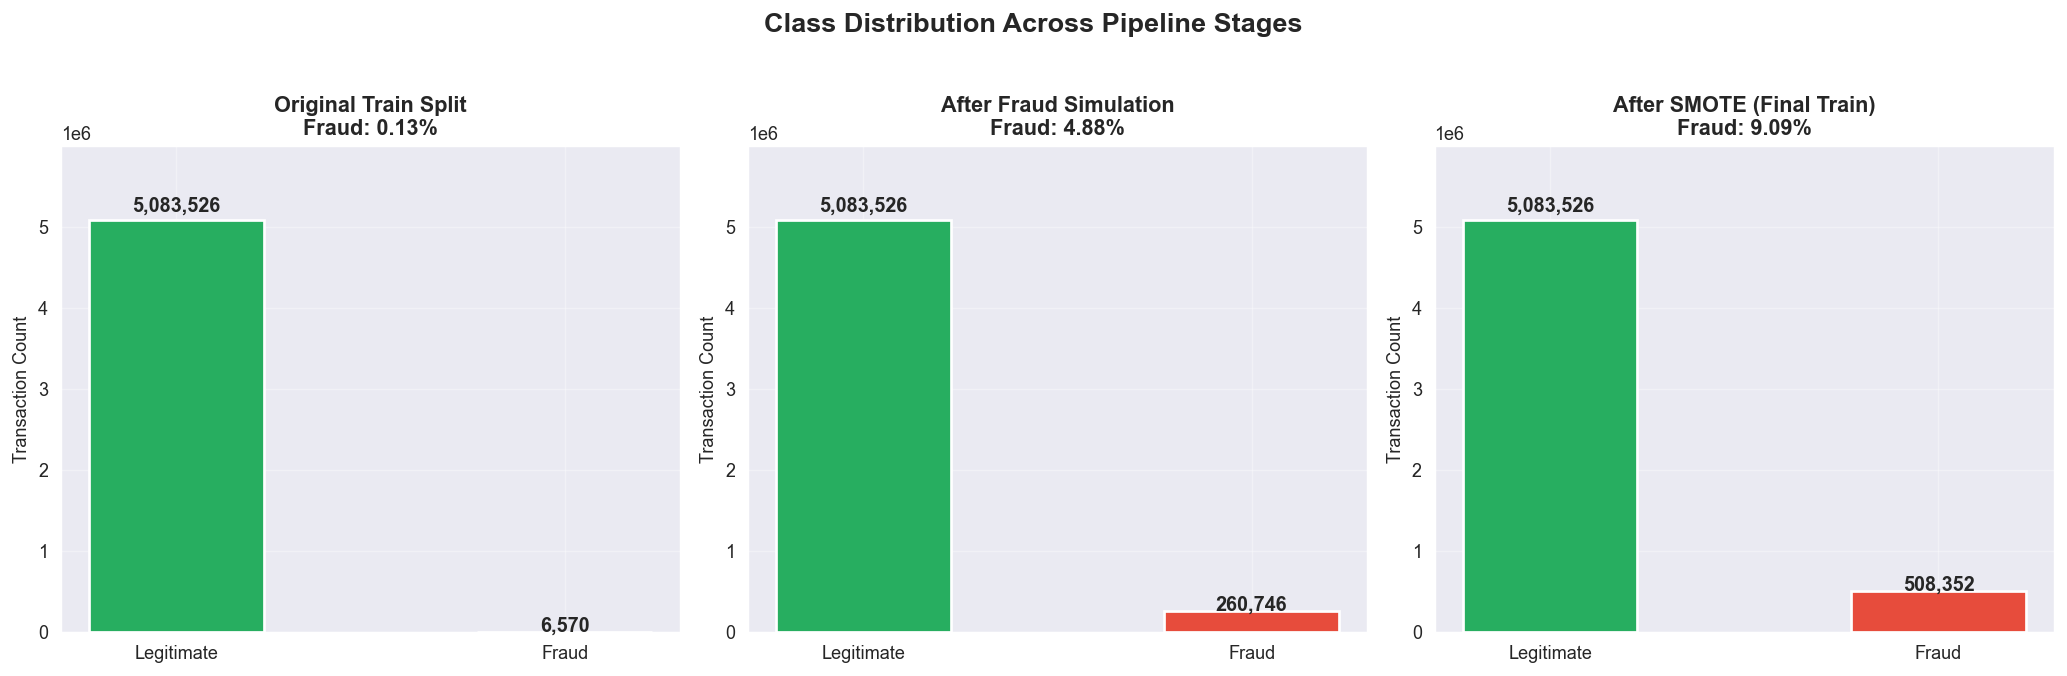

Class distribution chart saved.


In [77]:
# ── EDA: Class distribution at each pipeline stage

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

stages = [
    ("Original Train Split",        y_train),
    ("After Fraud Simulation",      y_train_aug),
    ("After SMOTE (Final Train)",   pd.Series(y_train_smote)),
]

for ax, (title, y_data) in zip(axes, stages):
    counts  = pd.Series(y_data).value_counts().sort_index()
    labels  = ['Legitimate', 'Fraud']
    colors  = [C['green'], C['red']]
    bars    = ax.bar(labels, counts.values, color=colors, width=0.45,
                     edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{val:,}', ha='center', fontsize=11, fontweight='bold')
    pct = counts[1] / counts.sum() * 100
    ax.set_title(f"{title}\nFraud: {pct:.2f}%", fontsize=12, fontweight='bold')
    ax.set_ylabel("Transaction Count", fontsize=10)
    ax.set_ylim(0, counts.max() * 1.18)

fig.suptitle("Class Distribution Across Pipeline Stages", fontsize=15,
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("outputs/plots/eda_class_distribution.png", bbox_inches='tight')
plt.show()
plt.close('all')
print("Class distribution chart saved.")

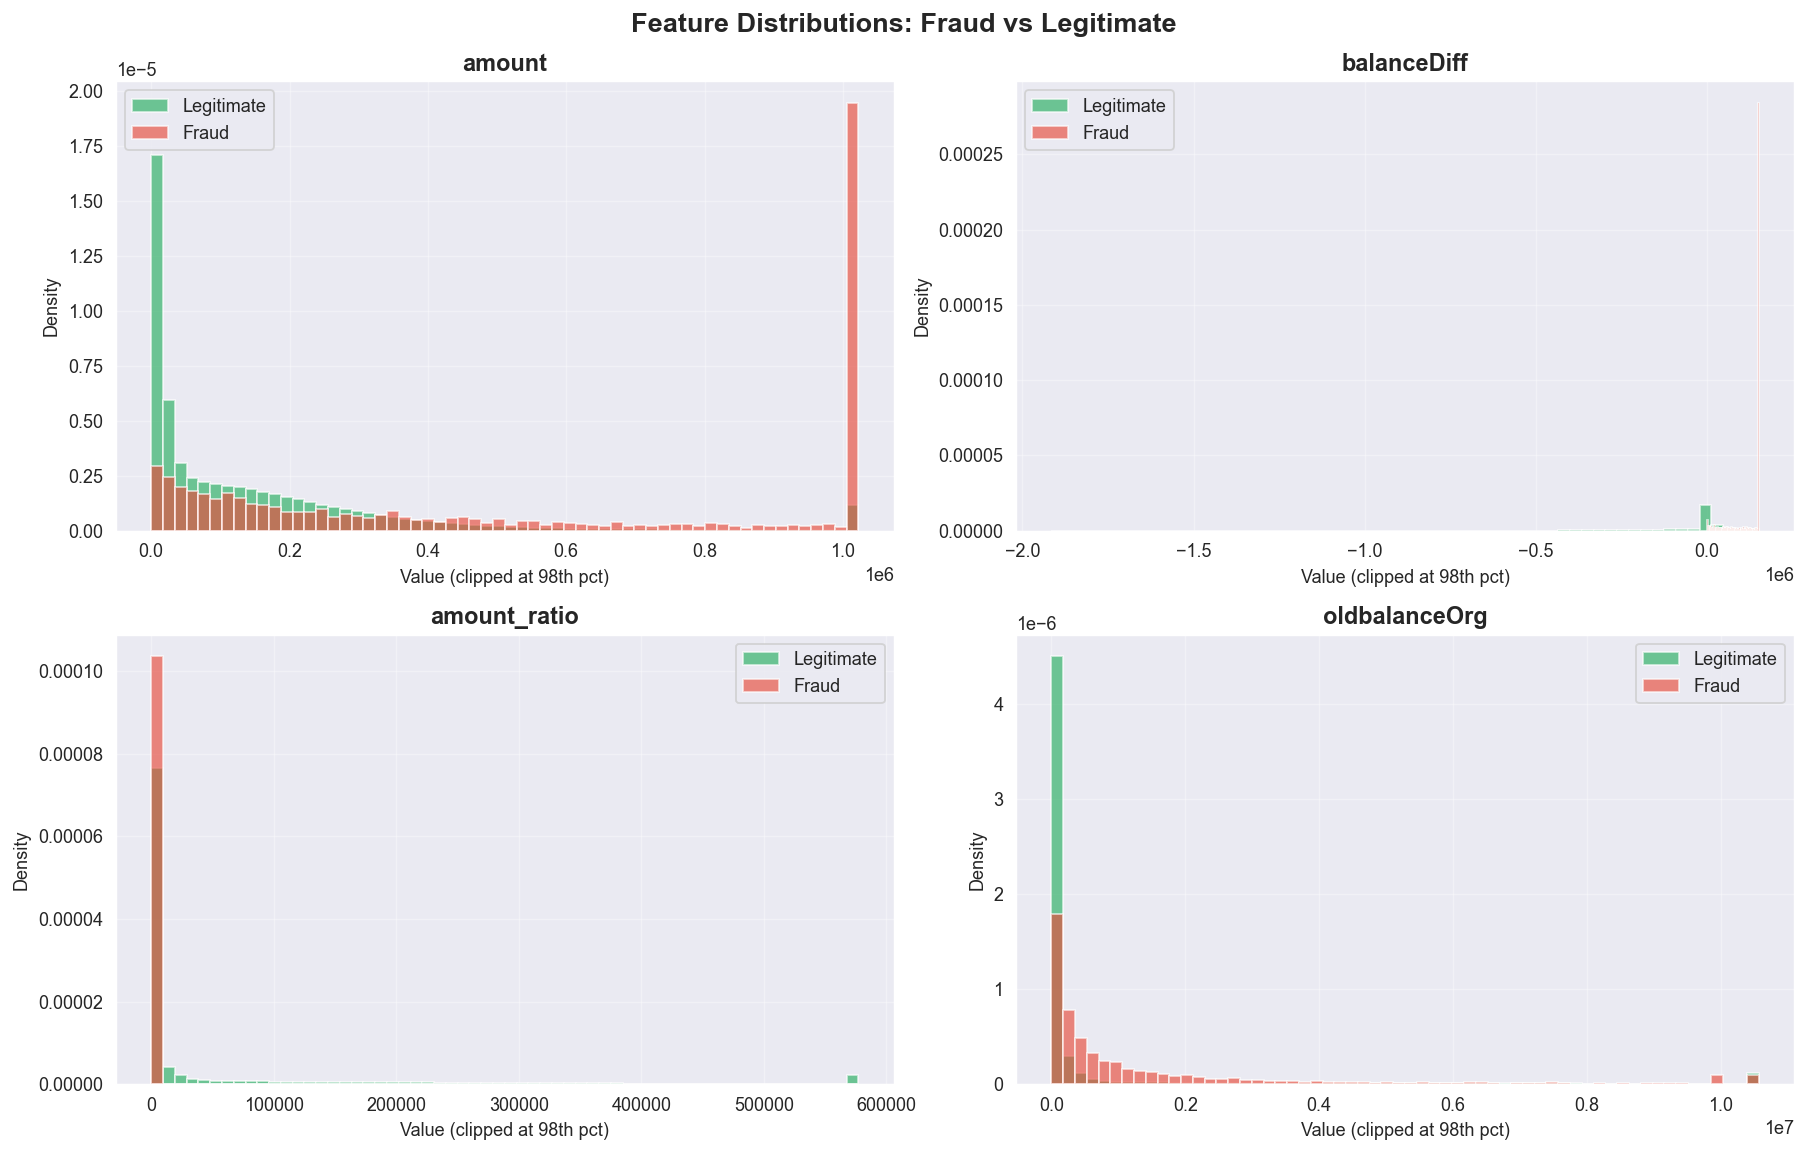

Feature distribution chart saved.


In [78]:
# ── EDA: Feature distributions — fraud vs legitimate

X_eda  = X_train.copy()
X_eda['isFraud'] = y_train.values

plot_cols = ['amount', 'balanceDiff', 'amount_ratio', 'oldbalanceOrg']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    if col in X_eda.columns:
        legit = X_eda[X_eda['isFraud'] == 0][col].clip(
            upper=X_eda[col].quantile(0.98))
        fraud = X_eda[X_eda['isFraud'] == 1][col].clip(
            upper=X_eda[col].quantile(0.98))
        ax.hist(legit, bins=60, color=C['green'], alpha=0.65, label='Legitimate', density=True)
        ax.hist(fraud, bins=60, color=C['red'],   alpha=0.65, label='Fraud',      density=True)
        ax.set_title(col, fontsize=13, fontweight='bold')
        ax.set_xlabel("Value (clipped at 98th pct)", fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.legend(fontsize=10)

fig.suptitle("Feature Distributions: Fraud vs Legitimate", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/plots/eda_feature_distributions.png", bbox_inches='tight')
plt.show()
plt.close('all')
print("Feature distribution chart saved.")

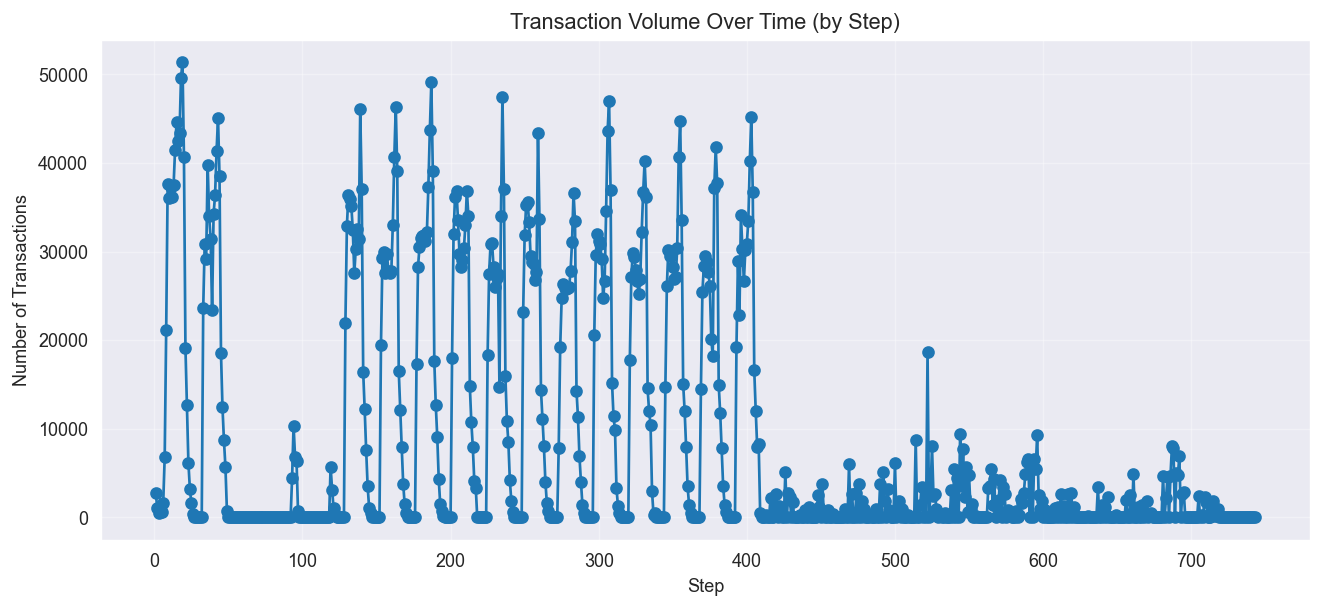

In [79]:
# 1. Transaction Volume Over Time
# Concept: Detect seasonal or temporal trends in transaction activity. Sudden spikes may indicate fraud bursts.
# Technical Insight: Use time-series aggregation of transaction counts by day/week/month.

# The 'transaction_date' column does not exist. Using 'step' as a proxy for time.
time_series = df.groupby('step').size()

plt.figure(figsize=(12,5))
plt.plot(time_series, marker='o')
plt.title('Transaction Volume Over Time (by Step)')
plt.xlabel('Step')
plt.ylabel('Number of Transactions')

plt.grid(True)
plt.savefig("outputs/plots/transaction_volume_over_time.png", dpi=300, bbox_inches="tight")
del time_series
plt.show()

In [86]:
# 2. Fraudulent vs Legitimate Transaction Distribution
# Concept: Compare class imbalance visually. Essential for imbalanced classification problems.
# Technical Insight: Bar charts or pie charts for categorical understanding.

def fraud_distribution(df_smote):

    plt.figure(figsize=(6,4))
    sns.countplot(
        x="isFraud",
        hue="isFraud",
        data=df_smote,
        order=[0, 1],
        hue_order=[0, 1],
        palette=[C['green'], C['red']],
        legend=False
    )
    plt.xlabel("Transaction Type", fontsize=10)
    plt.ylabel("Number of Transactions", fontsize=10)
    plt.title("Fraud vs Non-Fraud Transactions")
    plt.xticks([0, 1], ['Legitimate', 'Fraud'])
    plt.tight_layout()
    plt.grid(True)

    plt.savefig("outputs/plots/fraud_distribution.png")
    plt.show()

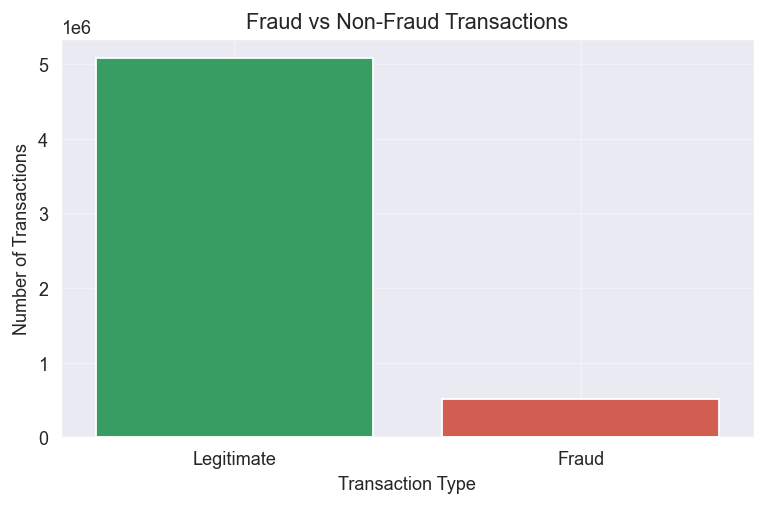

In [87]:
fraud_distribution(df_smote)

In [ ]:
# 3. Transaction types Distribution
def transaction_types(df_original, n_rows=30000):
    # Use only first n_rows to speed up plotting and reduce memory usage
    df_plot = df_original.head(n_rows)

    # medium-dark, readable colors (no pink)
    type_palette = ['#2E86C1', '#16A085', '#27AE60', '#E67E22', '#7F8C8D']

    plt.figure(figsize=(8,5))
    sns.countplot(
        x="type",
        hue="type",          # avoids seaborn palette deprecation warning
        data=df_plot,
        palette=type_palette,
        legend=False
    )

    plt.title(f"Transaction Types Distribution (first {len(df_plot):,} rows)")
    plt.xlabel("Transaction Type")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True)
    plt.savefig("outputs/plots/transaction_types_distribution.png")
    plt.show()
    plt.close('all')

Dataset Loaded Successfully
Shape: (6362620, 11)
Memory Usage: 920.71 MB


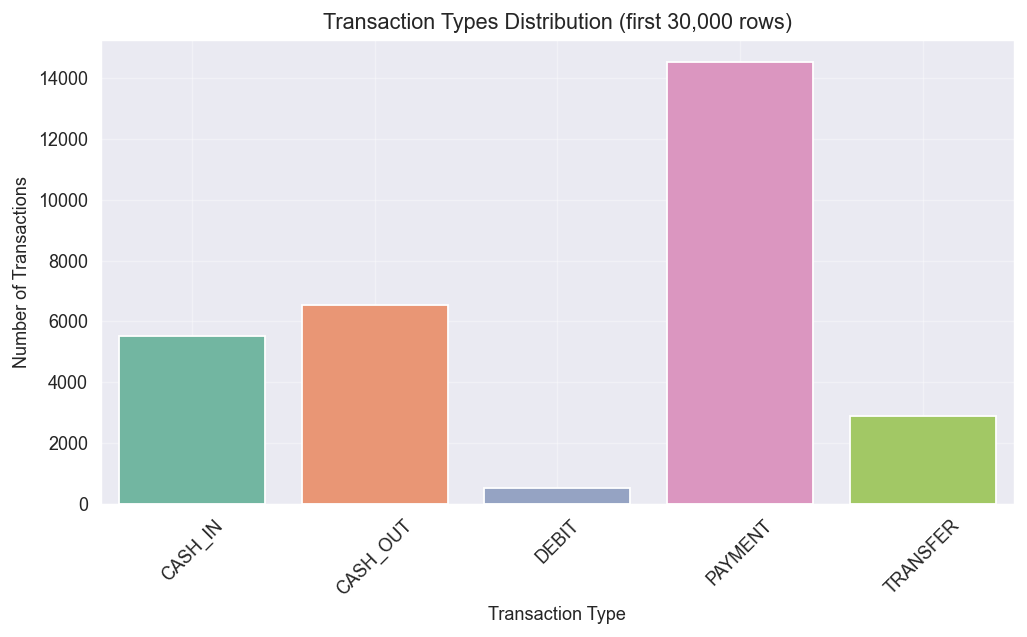

In [102]:
df_original = load_dataset(dataset_path)  # Reload original dataset to avoid memory issues

transaction_types(df_original, 30000)

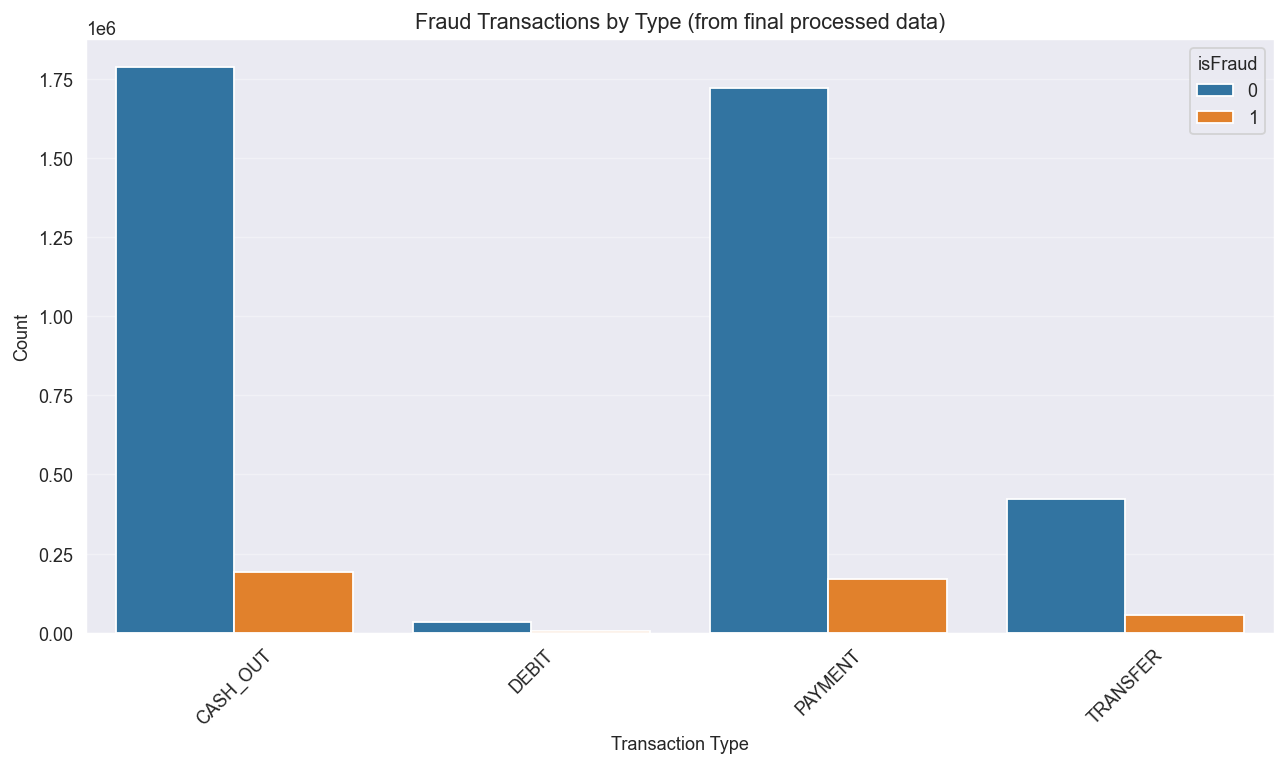

In [103]:
# 4. Fraud Transaction by Type

# Identify the one-hot encoded 'type' columns
type_columns = [col for col in df_smote.columns if col.startswith('type_')]

# Melt the DataFrame to bring the one-hot encoded columns into a single 'variable' column
# and their values into a 'value' column.
# Filter only for rows where 'value' is True (i.e., the transaction is of that type)
df_melted_types = df_smote.melt(id_vars=['isFraud'], value_vars=type_columns, var_name='transaction_type_encoded', value_name='is_this_type')
df_melted_types = df_melted_types[df_melted_types['is_this_type'] == True]

# Rename the transaction_type_encoded to a cleaner 'type' for plotting
df_melted_types['type'] = df_melted_types['transaction_type_encoded'].str.replace('type_', '')

plt.figure(figsize=(10, 6))
sns.countplot(x="type", hue="isFraud", data=df_melted_types)

plt.title("Fraud Transactions by Type (from final processed data)")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/plots/fraud_by_transaction_type.png", dpi=300)
plt.show()

# MEMORY ADDITION #12 — close figure from memory and free melted DataFrame
plt.close('all')
del df_melted_types

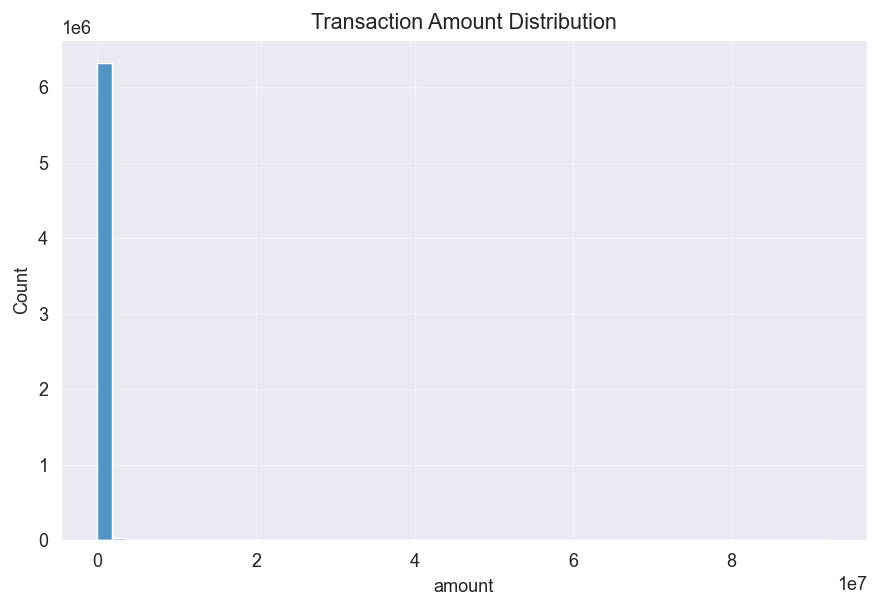

In [104]:
# 5. Transaction Amount Distribution
# Visualizing transaction amount distribution helps understand
# skewness and the need for feature scaling.

plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.savefig("outputs/plots/transaction_amount_distribution.png", dpi=300, bbox_inches="tight")

plt.grid(True)
plt.show()
# MEMORY ADDITION #13 — close figure from memory
plt.close('all')

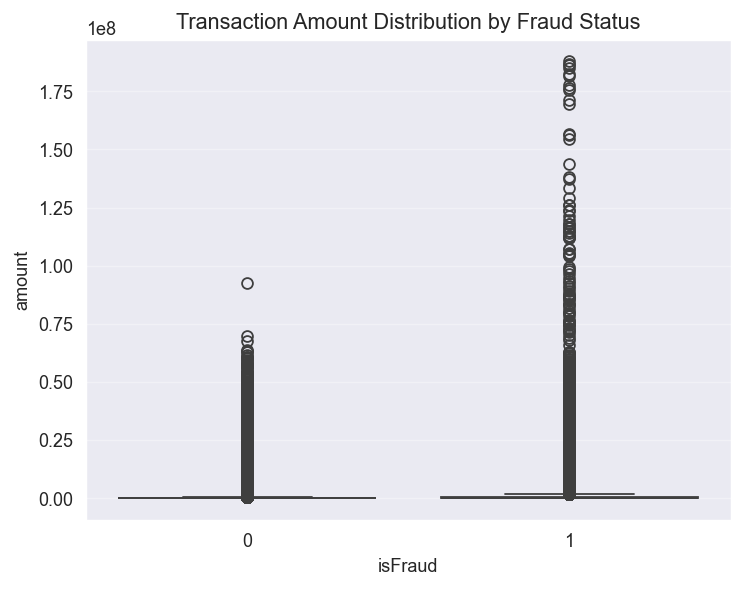

In [105]:
# 6. Transaction Amount Distribution by Fraud Status
# Concept: Fraud often shows unusual transaction amounts.
# Technical Insight: Boxplots or violin plots highlight outliers and distribution skew.

sns.boxplot(x='isFraud', y='amount', data=df_smote)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.savefig("outputs/plots/fraud_vs_normal_transaction_amounts.png", dpi=300, bbox_inches="tight")
plt.show()
# MEMORY ADDITION #14 — close figure from memory
plt.close('all')

In [106]:
# 8. Correlation Heatmap
# Concept: Identify relationships between numeric features; helps detect potential predictive features.
# Technical Insight: Strong correlations can guide feature engineering or indicate redundancy.
# This heatmao shows the numeric features distribution before scalarization, fraud simulation and SMOTE
def correlation_heatmap(df):

    plt.figure(figsize=(10,8))

    # Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=[np.number])
    sns.heatmap(numerical_df.corr(), cmap="rocket", annot=True, fmt=".2f")

    plt.title("Feature Correlation Heatmap")

    plt.savefig("outputs/plots/correlation_heatmap_1.png")
    plt.show()
    plt.close('all')

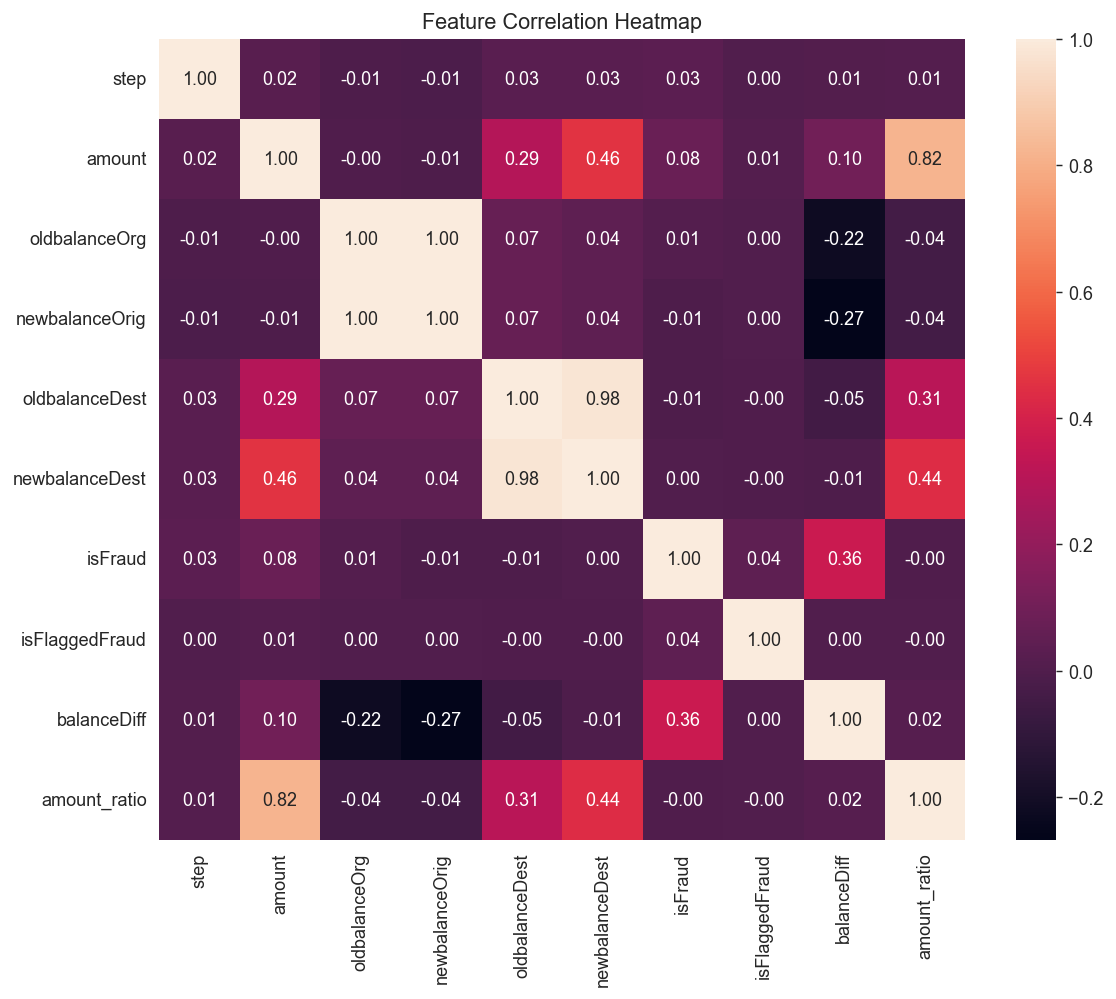

In [107]:
correlation_heatmap(df)

In [108]:
# 10. Top Fraud Patterns (Mean comparison)
def plot_fraud_patterns(df_smote):
    mean_df = df_smote.groupby('isFraud')[['amount', 'balanceDiff']].mean()

    ax = mean_df.plot(
        kind='bar',
        figsize=(8, 5),
        color=[C['blue'], C['orange']],   # reasonable contrasting colors
        edgecolor='white',
        width=0.75
    )

    ax.set_title("Fraud Pattern Comparison")
    ax.set_xlabel("Class")
    ax.set_ylabel("Mean Value")
    ax.set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
    ax.legend(title="Feature")
    plt.tight_layout()

    plt.savefig("outputs/plots/top_fraud_patterns.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close('all')

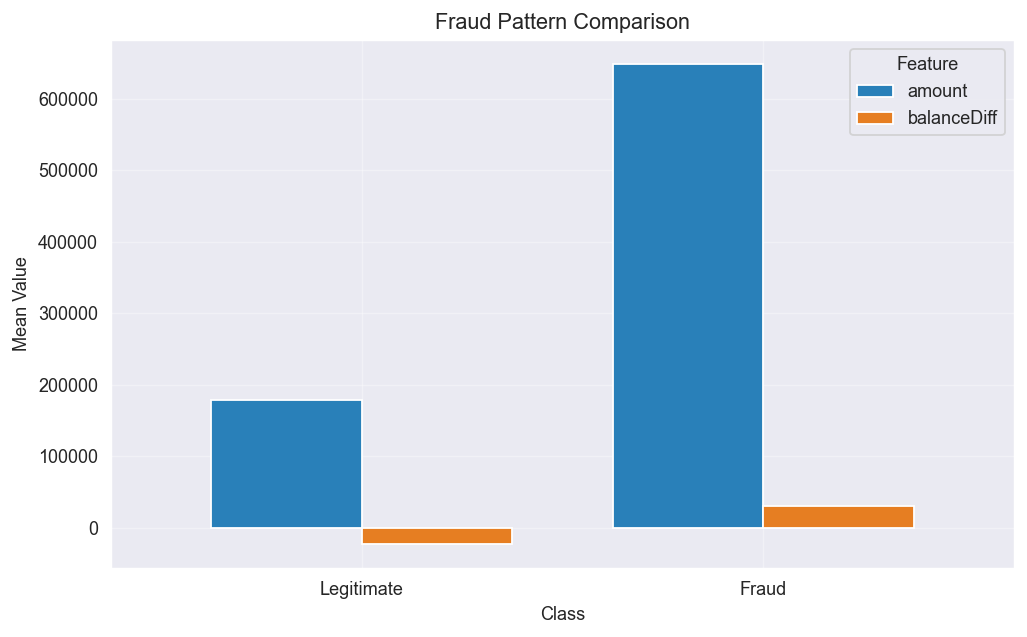

In [109]:
plot_fraud_patterns(df_smote)

In [110]:
# 11. Class Imbalance Visualization
def plot_class_imbalance(df_smote):
    counts = df_smote['isFraud'].value_counts(normalize=True).sort_index()

    ax = counts.plot(
        kind='pie',
        figsize=(6, 6),
        autopct='%1.1f%%',
        startangle=90,
        colors=[C['green'], C['red']],   # Legitimate, Fraud
        labels=['Legitimate', 'Fraud'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
        textprops={'fontsize': 10}
    )

    ax.set_ylabel('')
    plt.title("Class Imbalance Ratio")
    plt.tight_layout()

    plt.savefig("outputs/plots/class_imbalance.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close('all')

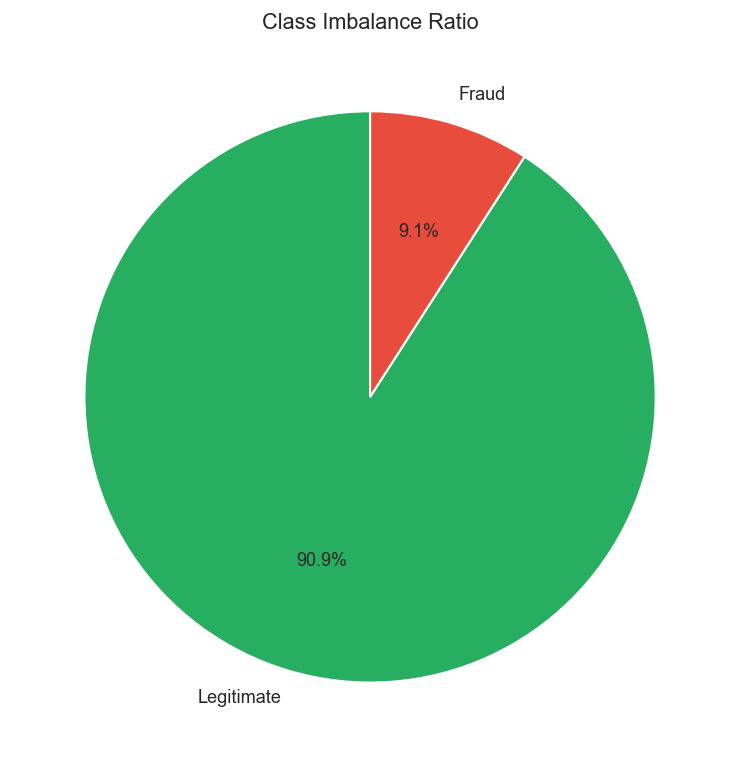

In [111]:
plot_class_imbalance(df_smote)

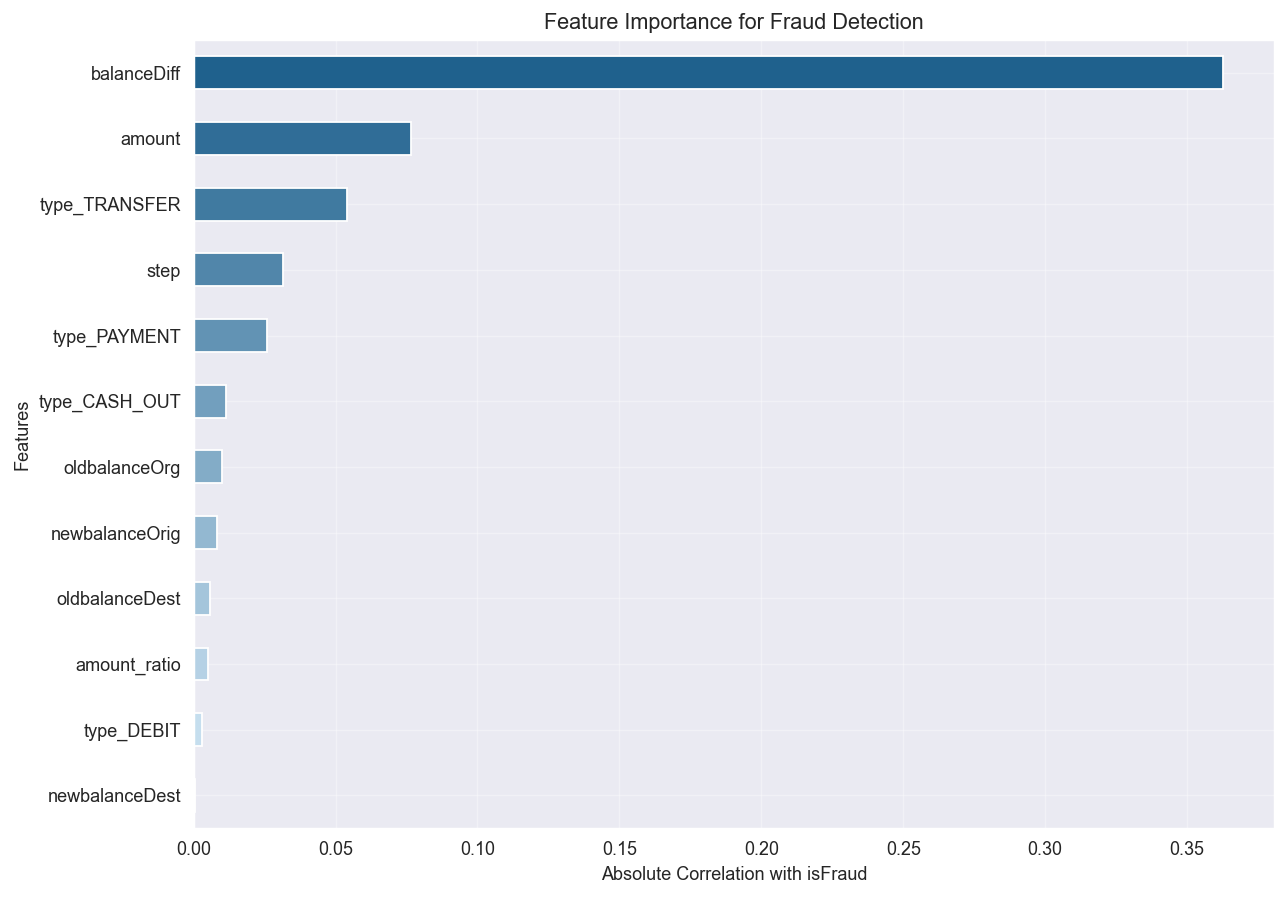

In [112]:
# 14. Feature Importance using Correlation (No ML model needed)
features = df.drop(columns=['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud'])

importances = features.corrwith(df['isFraud']).abs().sort_values()

# soft-to-strong color ramp (low -> high importance)
bar_colors = sns.color_palette("blend:#d6eaf8,#1f618d", n_colors=len(importances))

ax = importances.plot(
    kind='barh',
    figsize=(10, 7),
    color=bar_colors,
    edgecolor='white',
    linewidth=1.0
)

ax.set_title('Feature Importance for Fraud Detection')
ax.set_xlabel('Absolute Correlation with isFraud')
ax.set_ylabel('Features')
plt.tight_layout()

plt.savefig("outputs/plots/feature_importance_1.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close('all')
del features, importances

In [ ]:
## Key Insights from EDA

# - The original dataset exhibited severe class imbalance, with fraudulent transactions representing a very small percentage of the total data. This imbalance was identified as a major challenge for model training.
# - Fraudulent activities were primarily concentrated in specific transaction types, particularly TRANSFER and CASH_OUT, indicating that certain transaction categories carry higher fraud risk.
# - Transaction amounts displayed a highly skewed distribution, with a small number of very large transactions. Fraud cases were often associated with higher transaction amounts and unusual balance changes.
# - Feature engineering, such as the creation of balance difference variables, helped capture hidden transactional anomalies and improved the interpretability of fraud patterns.
# - After applying the fraud simulation engine, the diversity and frequency of fraudulent transactions increased, making fraud patterns more visible and learnable.
# - The application of SMOTE with a sampling ratio of 0.1 significantly improved class balance while maintaining a realistic distribution between fraudulent and non-fraudulent transactions.
# - Comparative analysis between training and testing datasets confirmed that the test set remained untouched, ensuring no data leakage and preserving unbiased evaluation.
# - Feature scaling was applied as the final preprocessing step to standardize numerical features, enabling better performance and stability of machine learning models.
# - Post-processing EDA confirmed that the dataset is now more balanced, structured, and suitable for training robust fraud detection models.

## scripts/save_cleaned_dataset.py
Save the cleaned and preprocessed dataset for future model training and analysis.

In [48]:
# Saving Dataset after doing the cleaning + processing + scalarization + fraud_simulation + SOMET


def save_dataset(df, filename, folder="outputs/processed_data/"):
    """
    Generic save function
    """

    # Ensure the target folder exists
     # Cleaned + Processed Dataset
    os.makedirs(folder, exist_ok=True)

    path = os.path.join(folder, filename)
    df.to_csv(path, index=False)

    print(f"Saved: {path}")
    print(f"Shape: {df.shape}")

In [49]:
save_dataset(df, "processed_paysim.csv")

Saved: outputs/processed_data/processed_paysim.csv
Shape: (6362620, 16)


In [50]:
print(df.head())

   step        amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   9839.639648  C1231006815       170136.0   160296.359375   
1     1   1864.280029  C1666544295        21249.0    19384.720703   
2     1    181.000000  C1305486145          181.0        0.000000   
3     1    181.000000   C840083671          181.0        0.000000   
4     1  11668.139648  C2048537720        41554.0    29885.859375   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
0  M1979787155             0.0             0.0        0               0   
1  M2044282225             0.0             0.0        0               0   
2   C553264065             0.0             0.0        1               0   
3    C38997010         21182.0             0.0        1               0   
4  M1230701703             0.0             0.0        0               0   

    balanceDiff  amount_ratio  type_CASH_OUT  type_DEBIT  type_PAYMENT  \
0   9839.640625      0.057834          False       False    

In [51]:
def save_pipeline_outputs(df_train, df_test, df_aug, df_final):
    """
    Save all pipeline stages
    """

    print("\n===== SAVING ALL DATASETS =====")

    # 1. Original Train/Test
    save_dataset(df_train, "train_original.csv")
    save_dataset(df_test, "test_original.csv")

    # 2. After Fraud Simulation
    save_dataset(df_aug, "train_after_simulation.csv")

    # 3. After SMOTE (Final Training Data)
    save_dataset(df_final, "train_final_smote.csv")

    print("\n All datasets saved successfully!")

In [52]:
save_pipeline_outputs(df_train, df_test, df_aug, df_final)


===== SAVING ALL DATASETS =====
Saved: outputs/processed_data/train_original.csv
Shape: (6107909, 13)
Saved: outputs/processed_data/test_original.csv
Shape: (1272524, 13)
Saved: outputs/processed_data/train_after_simulation.csv
Shape: (5344272, 13)
Saved: outputs/processed_data/train_final_smote.csv
Shape: (5591878, 13)

 All datasets saved successfully!


## Summary

The PaySim dataset was analyzed and processed to understand transaction behavior and improve fraud detection capability. Initial analysis revealed that fraudulent activities were primarily concentrated in **TRANSFER** and **CASH_OUT** transaction types, with fraud cases often involving unusually large transaction amounts and abnormal balance changes, such as accounts being completely drained or destination accounts showing inconsistent balances.

A major challenge identified in the dataset was severe class imbalance, where fraudulent transactions represented only a very small fraction of the total data. To address this limitation, a structured preprocessing pipeline was implemented.

To improve fraud representation, a **Fraud Simulation Engine** was introduced as a core innovation. This step generated additional synthetic fraud transactions based on observed behavioral patterns, increasing both the diversity and realism of fraud cases.

Following this, **SMOTE (Synthetic Minority Oversampling Technique)** was applied with a sampling ratio of **0.1**, increasing the proportion of fraudulent transactions while maintaining a realistic imbalance. This approach ensured that the model can learn fraud patterns effectively without overfitting to artificially balanced data.

Finally, feature scaling was applied using training-based parameters to standardize numerical features, improving model performance and stability.